<a href="https://colab.research.google.com/github/Bryan-ing/Master-s-Degree-in-AI/blob/main/Tarea4_Pruebas_Hipotesis_Estudiantes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Tarea Clase 4: Pruebas de Hipotesis
## Maestria en Inteligencia Artificial

**Tiempo estimado:** 1-2 horas
**Dataset:** BRFSS (Behavioral Risk Factor Surveillance System)

### Instrucciones
Completa los ejercicios marcados con **# TU CODIGO AQUI**. Cada ejercicio tiene pistas para ayudarte.

**Nota:** Este notebook utiliza el dataset BRFSS real de Allen Downey (2014).

---
## 0. Configuracion Inicial

In [1]:
# Importar librerias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats
from scipy.stats import ttest_ind

%matplotlib inline

print('Librerias importadas')

Librerias importadas


---
## 1. Cargar el Dataset BRFSS

In [2]:
# Descargar y cargar datos BRFSS
import os
from urllib.request import urlretrieve

url = 'https://github.com/AllenDowney/ThinkStats2/raw/master/homeworks/brfss.hdf5' #se quita el blob y se pone el raw
filename = 'brfss.hdf5'
urlretrieve(url, filename)

('brfss.hdf5', <http.client.HTTPMessage at 0x7fde497abb30>)

---
## 2. Caso de Estudio: Diferencia de Peso entre Hombres y Mujeres

Investigaremos si existe una diferencia significativa en el peso entre hombres y mujeres usando el dataset BRFSS.

Variables del dataset:
- sex = 1: Hombre
- sex = 2: Mujer
- wtkg2: Peso en kilogramos

### EJERCICIO 1: Exploracion de Datos (15 puntos)

In [3]:
# EJERCICIO 1.1: Filtrar datos validos y separar por sexo
# PISTA: Filtra pesos entre 30 y 200 kg para eliminar valores atipicos

# TU CODIGO AQUI
brfss = pd.read_hdf(filename, 'brfss')
datos_validos = brfss[(brfss['WTKG3'] >= 30) & (brfss['WTKG3'] <= 200)].copy()

# Separar por sexo (1=Hombres, 2=Mujeres)
peso_hombres = datos_validos[datos_validos['SEX'] == 1]['WTKG3'].dropna()
peso_mujeres = datos_validos[datos_validos['SEX'] == 2]['WTKG3'].dropna()



In [4]:
# EJERCICIO 1.2: Calcula estadisticas descriptivas

# TU CODIGO AQUI
# Impresión de resultados
print("Comparación de Peso por Sexo:")
print(f"\nHombres (n={len(peso_hombres):,}):")
print(f"  Media: {peso_hombres.mean():.2f} kg")
print(f"  Mediana: {peso_hombres.median():.2f} kg")
print(f"  Desv. Estándar: {peso_hombres.std():.2f} kg")

print(f"\nMujeres (n={len(peso_mujeres):,}):")
print(f"  Media: {peso_mujeres.mean():.2f} kg")
print(f"  Mediana: {peso_mujeres.median():.2f} kg")
print(f"  Desv. Estándar: {peso_mujeres.std():.2f} kg")

Comparación de Peso por Sexo:

Hombres (n=46,433):
  Media: 88.73 kg
  Mediana: 86.18 kg
  Desv. Estándar: 19.70 kg

Mujeres (n=46,861):
  Media: 73.57 kg
  Mediana: 70.31 kg
  Desv. Estándar: 18.62 kg


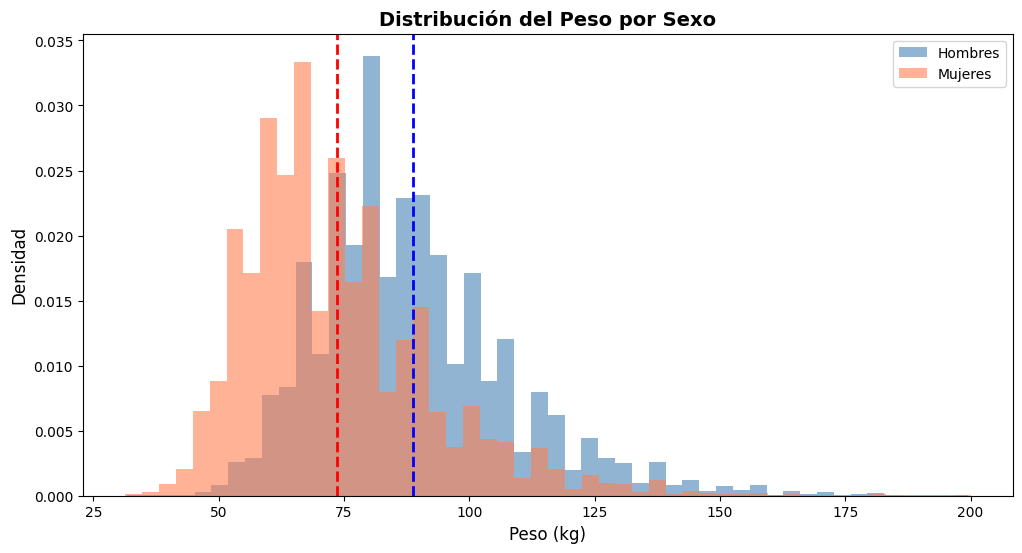

In [5]:
# EJERCICIO 1.3: Visualiza las distribuciones

fig, ax = plt.subplots(figsize=(12, 6))

# TU CÓDIGO AQUÍ
ax.hist(peso_hombres, bins=50, alpha=0.6, label='Hombres', color='steelblue', density=True)
ax.hist(peso_mujeres, bins=50, alpha=0.6, label='Mujeres', color='coral', density=True)

ax.axvline(peso_hombres.mean(), color='blue', linestyle='--', linewidth=2)
ax.axvline(peso_mujeres.mean(), color='red', linestyle='--', linewidth=2)

ax.set_xlabel('Peso (kg)', fontsize=12)
ax.set_ylabel('Densidad', fontsize=12)
ax.set_title('Distribución del Peso por Sexo', fontsize=14, fontweight='bold')
ax.legend()
plt.show()

# TU CODIGO AQUI: Completa los parametros faltantes


---
## 3. Prueba de Hipotesis

### EJERCICIO 2: Formular Hipotesis (10 puntos)

Completa las hipotesis para este estudio:

**H0 (Hipotesis Nula):** No hay cambio entre el peso de Mujeres y Hombres, se matiene igual y no afecta nada($\mu_1 = \mu_2$).

**H1 (Hipotesis Alternativa):** Cambia drasticamente la diferencia entre hombres y mujeres ($\mu_1 \neq \mu_2$).

**Nivel de significancia:** alfa = 0.05

### EJERCICIO 3: Prueba de Permutacion (25 puntos)
Sirve para saber ¿La diferencia es real o fue suerte? → p-value

In [12]:
def run_permutation_test(group1_data, group2_data, num_permutations=10000): #define la funcion que toma como argumentos
#los datos de los dos grupos, y el numero final es el numero de permutaciones a realizar:10000
    # 1. Diferencia observada
    observed_diff = group1_data.mean() - group2_data.mean() #esta funcion calcula la diferencia real
    #entre las medias de cada grupo

    # 2. Combinar datos
    combined_data = np.concatenate((group1_data, group2_data)) #combina los datos de ambos grupos en un solo conjunto
    #para la hipotesis nula los datos provienen de la misma población

    # 3. Permutaciones
    diffs = []
    for _ in range(num_permutations):
        np.random.shuffle(combined_data) #revuelve todos los numeros aleatoriamente
        perm_group1 = combined_data[:len(group1_data)] #toma los primeros 5 elementos para un grupo permutado
        perm_group2 = combined_data[len(group1_data):] #toma el resto de elementos para formar el segundo grupo permutado
        diffs.append(perm_group1.mean() - perm_group2.mean()) #calcula la diferencia de medias entre estos dos grupos y se
        #se añade a la lista diffs

    # 4. Calcular p-value (prueba de dos colas)
    diffs = np.array(diffs)
    p_value = np.sum(np.abs(diffs) >= np.abs(observed_diff)) / num_permutations #calculamos el p-value
    #unp-value bajo sugiere que es poco probable que la diferencia haya surgido al azar

    return observed_diff, diffs, p_value

In [15]:
observed_diff, perm_diffs, p_value = run_permutation_test(peso_hombres, peso_mujeres)

print(f"Diferencia observada de medias (Hombres - Mujeres): {observed_diff:.2f} kg")
print(f"P-valor (prueba de permutación): {p_value:.4f}") #Como p-value = 0 (es prácticamente imposible que esto ocurra por azar)
#→ rechazas H0 → la diferencia de peso entre hombres y mujeres es real, no es suerte.

Diferencia observada de medias (Hombres - Mujeres): 15.15 kg
P-valor (prueba de permutación): 0.0000


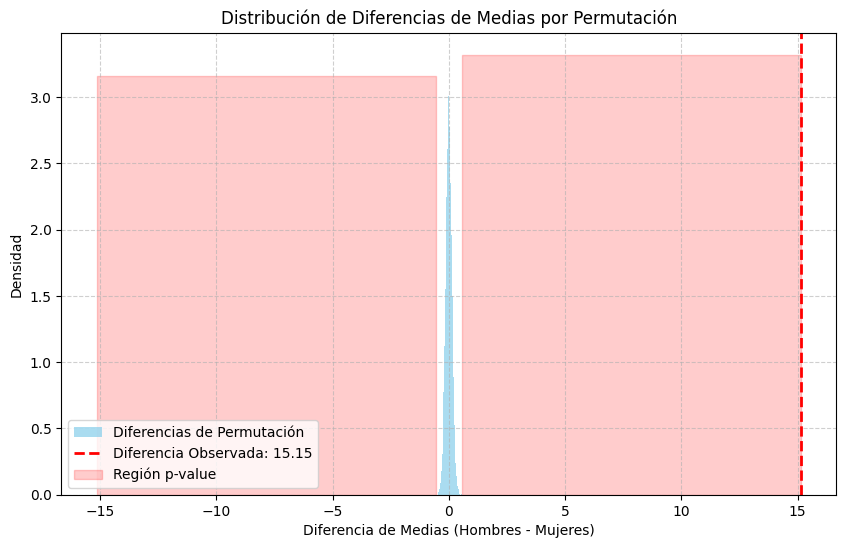

In [16]:
# EJERCICIO 3.3: Visualiza la distribucion de permutaciones

# TU CODIGO AQUI: Completa los parametros faltantes
# 1. Histograma de diferencias de permutacion
plt.figure(figsize=(10, 6))
plt.hist(perm_diffs, bins=50, density=True, alpha=0.7, color='skyblue', label='Diferencias de Permutación')

# 2. Linea vertical para la diferencia observada
plt.axvline(observed_diff, color='red', linestyle='dashed', linewidth=2, label=f'Diferencia Observada: {observed_diff:.2f}')

# 3. Sombrear region de p-value (valores mas extremos)
# Para una prueba de dos colas, sombreamos ambas colas
# la región donde la magnitud de la diferencia de permutación es mayor o igual a la magnitud de la diferencia observada

# Obtener los límites para sombrear
lower_bound = -np.abs(observed_diff)
upper_bound = np.abs(observed_diff)

# Sombrear la cola izquierda
plt.fill_betweenx([0, plt.ylim()[1]], min(perm_diffs), lower_bound, color='red', alpha=0.2, label='Región p-value')
# Sombrear la cola derecha
plt.fill_betweenx([0, plt.ylim()[1]], upper_bound, max(perm_diffs), color='red', alpha=0.2)


plt.title('Distribución de Diferencias de Medias por Permutación')
plt.xlabel('Diferencia de Medias (Hombres - Mujeres)')
plt.ylabel('Densidad')
plt.legend()
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**EXPLICACIÓN: **
H0 dice: los grupos son iguales, no hay diferencia real.
El loop simula ese mundo donde H0 es verdadera, revolviendo los datos 10,000 veces.
El resultado del loop: ninguna de esas 10,000 permutaciones produjo una diferencia de 15.15 → p-value = 0.
Tus datos reales sí tienen una diferencia de 15.15.
Conclusión: tus datos son imposibles en el mundo de H0 → H0 está mal → la rechazas.

**Explicación de la grafica: **
La campana es como sería si H0 fuera cierta->La campana azul es el mundo ficticio donde no hay diferencia real, simulado por el loop.

Linea Roja: es lo que realmente es y donde van los valores reales->La línea roja es tu diferencia real con tus datos originales.


P-value: Cuánta campana azul hay dentro de la región rosada.
Región Rosada: Zona donde la campana tendría que entrar para apoyar H0.


### EJERCICIO 4: Prueba t de Student (25 puntos)

Sirve para saber ¿Entre qué valores está la diferencia real? → intervalo

In [22]:
# EJERCICIO 4.1: Realiza la prueba t de Student

# TU CODIGO AQUI
t_statistic, p_value_ttest = ttest_ind(peso_hombres, peso_mujeres, equal_var=False) # Welch's t-test
#esta función "ttest_ind" compaa las medias de dos muestras independientes

#equal_var=False es un parámetro importante que indica que no se asume que las varianzas de las dos poblaciones son iguales.
#Cuando esta configuración es False, la función realiza la prueba t de Welch,
#que es más robusta cuando las varianzas son diferentes, como suele ser el caso en datos reales.

print(f"Estadístico t de Student: {t_statistic:.2f}") #imprime el valor del estadístico t calculado.
print(f"P-valor (prueba t de Student): {p_value_ttest:.4f}") # imprime el p-valor obtenido de la prueba t

Estadístico t de Student: 120.69
P-valor (prueba t de Student): 0.0000


In [24]:
# EJERCICIO 4.2: Calcula el intervalo de confianza 95%
#No te dice un valor exacto sino un rango donde probablemente está la diferencia real.
#En tu caso al 95% significa:
#Estoy 95% seguro de que la diferencia real de peso entre hombres y mujeres está entre X y Y kg

# TU CODIGO AQUI

# Error estandar
sem1 = peso_hombres.sem()
sem2 = peso_mujeres.sem()
std_err_diff = np.sqrt(sem1**2 + sem2**2)
#Mide qué tanto puede variar tu diferencia de medias si tomaras otras muestras.
#Entre más pequeño, más preciso eres.

# Grados de libertad (aproximacion de Welch)
n1 = len(peso_hombres)
n2 = len(peso_mujeres)
df = (sem1**2 + sem2**2)**2 / ((sem1**2)**2 / (n1 - 1) + (sem2**2)**2 / (n2 - 1))
#Es una corrección que se usa cuando los dos grupos tienen varianzas diferentes.
#Los grados de libertad le dicen a la t de Student qué tan anchas deben ser sus colas


# Valor critico t
critical_value = stats.t.ppf(0.975, df) # 0.975 para 95% de confianza
#Es el punto en la distribución t donde el 95% de los datos quedan adentro.
#El 0.975 es porque son dos colas, entonces 2.5% queda en cada extremo.


# Intervalo de confianza
lower_bound_ci = observed_diff - critical_value * std_err_diff
upper_bound_ci = observed_diff + critical_value * std_err_diff
#Tu diferencia real ± un margen de error. Eso es el intervalo.El critical_value * std_err_diff es el margen de error,
#es decir cuánto te puedes alejar de tu diferencia real hacia cada lado para cubrir el 95%.

print(f"Error estándar de la diferencia de medias: {std_err_diff:.2f}")
print(f"Grados de libertad (aproximación de Welch): {df:.2f}")
print(f"Valor crítico t para 95% de confianza: {critical_value:.2f}")
print(f"Intervalo de confianza del 95%: [{lower_bound_ci:.2f}, {upper_bound_ci:.2f}] kg")

Error estándar de la diferencia de medias: 0.13
Grados de libertad (aproximación de Welch): 92896.50
Valor crítico t para 95% de confianza: 1.96
Intervalo de confianza del 95%: [14.91, 15.40] kg


Error estándar = 0.13
No es la diferencia entre medias. Es qué tanto podría variar esa diferencia si repitieras el estudio con otras personas. Un 0.13 muy pequeño significa que tu estimación de 15.15 es muy precisa.


Grados de libertad = 92,896.50
Es un número muy grande porque tienes muchos datos. Entre más datos tienes, más se parece la t de Student a una gaussiana normal y más confiable es tu resultado.

Valor crítico t = 1.96
Es el multiplicador que define qué tan ancho es tu intervalo. Con 95% siempre sale cerca de 1.96.


Intervalo de confianza = [14.91, 15.40] kg
Esto es lo más importante. Significa:

"Estoy 95% seguro de que la diferencia real de peso entre hombres y mujeres está entre 14.91 y 15.40 kg"

---
## 4. Tamano del Efecto

### EJERCICIO 5: Cohen's d (15 puntos)

El Cohen's d mide el tamano del efecto en unidades de desviacion estandar. Cohen's d nos dice qué tan grande es esa diferencia en términos prácticos.

**Formula:** d = (x1_media - x2_media) / s_agrupada

In [25]:
# EJERCICIO 5.1: Calcula Cohen's d

# TU CODIGO AQUI
# Desviacion estandar agrupada (pooled)
# Esta fórmula calcula una desviación estándar combinada de ambos grupos.
# Se utiliza para tener una medida de variabilidad que no esté sesgada hacia un solo grupo,
# asumiendo que ambos grupos provienen de poblaciones con varianzas similares (aunque la prueba t de Welch no lo asuma).
# Esencialmente, es un promedio ponderado de las varianzas de los dos grupos.
s_pooled = np.sqrt(((len(peso_hombres) - 1) * peso_hombres.std()**2 + \
                    (len(peso_mujeres) - 1) * peso_mujeres.std()**2) / \
                   (len(peso_hombres) + len(peso_mujeres) - 2))

# Cohen's d
# Cohen's d se calcula dividiendo la diferencia de medias observada (que ya calculaste) por la desviación estándar agrupada.
# Esto estandariza la diferencia, expresándola en "unidades de desviación estándar", lo que facilita la interpretación del tamaño del efecto.
cohens_d = observed_diff / s_pooled

print(f"Desviación estándar agrupada (pooled): {s_pooled:.2f} kg")
print(f"Cohen's d: {cohens_d:.2f}")

# Interpretacion
# Esta sección proporciona una interpretación cualitativa del valor de Cohen's d.
# Es una guía común para entender si el tamaño del efecto es pequeño, medio o grande.
# Un valor de 0.2 se considera pequeño, 0.5 medio y 0.8 grande.
if cohens_d < 0.2:
    interpretation = "muy pequeño"
elif cohens_d < 0.5:
    interpretation = "pequeño"
elif cohens_d < 0.8:
    interpretation = "medio"
else:
    interpretation = "grande"

print(f"Interpretación del tamaño del efecto: La diferencia es {interpretation}.")

Desviación estándar agrupada (pooled): 19.17 kg
Cohen's d: 0.79
Interpretación del tamaño del efecto: La diferencia es medio.


---
## 5. Resumen de Resultados

### EJERCICIO 6: Conclusiones (10 puntos)

Completa el siguiente resumen con tus hallazgos:

**Resumen de Resultados:**

| Metrica | Valor |
|---------|-------|
| Diferencia de medias | __15.15_ kg |
| p-value (permutacion) | __0_ |
| p-value (t-test) | _0_ |
| Intervalo de confianza 95% | [14.91, 15.40] kg |
| Cohen's d | __0.8_ |

**Conclusion:**

Escribe tu conclusion aqui. Responde las siguientes preguntas:
1. Hay diferencia significativa entre el peso de hombres y mujeres?Si, se refleja una diferencia de 15.15kg, esto nos permite descartar de inmediato nuestra hipotesis nula
2. Es practicamente importante esta diferencia?Claro ya que es un valor no alto pero significativo.Aunque 15.15 kg puede no ser una diferencia "enorme" en términos absolutos para un individuo, es una diferencia consistente y relevante a nivel poblacional esto lo hace relevante.
3. Que limitaciones tiene este analisis? La limitaciones que se presentan es que no se puede graficar directamente nuestra Hipotesis Alternativa, y por analisis y deducción debemos de hacerlo solo con la nula, dejando un rango de posible no exactitud en este analisis. Además:
El peso fue declarado por los participantes, lo que puede introducir sesgos (las personas a veces subestiman su peso).
Estudio observacional: No podemos establecer una relación de causa y efecto. Este estudio solo muestra una asociación. Hay muchos otros factores (como altura, dieta, nivel de actividad física, genética) que también influyen en el peso y que podrían diferir entre hombres y mujeres, pero no se controlan en este análisis.

### Pregunta 1: Interpretacion del p-value

Si obtuviste un p-value < 0.05, que significa esto en terminos practicos?
Que no significa? (Pista: No significa que la probabilidad de que H0 sea verdadera sea menor al 5%).

**Respuesta:**

Un p-value muy bajo (como 0.0000 en este caso) significa que, si la hipótesis nula (H0, es decir, que no hay diferencia real entre los pesos de hombres y mujeres) fuera verdadera, sería extremadamente improbable observar una diferencia tan grande o más grande que la que encontramos (15.15 kg).

Dado que es muy poco probable que esto ocurra por puro azar bajo H0, **rechazamos la hipótesis nula**.

Sin embargo, esto NO significa que H0 tenga solo 5% de probabilidad de ser verdadera. El p-value no mide la probabilidad de que la H0 sea verdadera o falsa, solo mide qué tan raros son tus datos asumiendo que H0 es verdadera.


### Pregunta 2: Significancia estadistica vs importancia practica

Con una muestra muy grande (como BRFSS con miles de registros),
es posible obtener una diferencia estadisticamente significativa
que sea muy pequena en terminos practicos.

- Como se relaciona el tamano del efecto (Cohen's d) con el p-value? nuestro tamaño del efecto es que tan separado esta la desviación estandar de la media, es decir que tan lejos del promedio se encuentran los defectos, mientras que el p-value refleja donde se encuentra
- Por que es importante reportar ambos?
- En que situaciones una diferencia de 2 kg en peso promedio seria importante?

**Respuesta:**

El **Cohen's d** y el **p-value** nos dicen cosas diferentes pero complementarias. El p-value (que salió casi 0) nos dice que la diferencia de peso entre hombres y mujeres no es por casualidad, que es estadísticamente significativa. Pero el **Cohen's d** (0.79) nos dice **qué tan grande es esa diferencia** en términos prácticos, es decir, qué tan importante es en el día a día.

Es crucial reportar ambos porque el p-value solo te dice si hay una diferencia, pero no te dice si esa diferencia es relevante en el mundo real. Con tantos datos, incluso una diferencia minúscula podría ser "estadísticamente significativa", pero Cohen's d nos ayuda a ver si esa diferencia realmente importa.


### Pregunta 3: Supuestos y limitaciones

Considera los siguientes aspectos del dataset BRFSS:

1. Los datos son autoreportados (las personas declaran su propio peso).

2. La muestra BRFSS incluye solo personas con telefono fijo o celular.
   Que poblaciones podrian estar subrepresentadas?

3. El dataset incluye personas de todas las edades adultas.
   Como afectaria el analisis si separaramos por grupos de edad?

**Respuesta:**

1.Como podria esto afectar los resultados?Que el peso sea reportado por las personas es un factor importante. A veces la gente no recuerda el peso exacto, lo redondea, o incluso puede subestimarlo un poco. Esto podría introducir un pequeño sesgo en las medias y desviaciones estándar, haciendo que los resultados sean un poco menos precisos de lo que serían con mediciones directas. Sin embargo, con una muestra tan grande, es probable que estos errores se diluyan un poco, pero es algo a tener en cuenta.

2.Esto significa que algunas poblaciones podrían no estar bien representadas. Por ejemplo, personas sin acceso a un teléfono, o aquellas que no tienen un domicilio fijo, o incluso grupos demográficos que utilizan menos el teléfono. Esto podría llevar a que los resultados no sean perfectamente generalizables a toda la población, especialmente a los grupos más vulnerables o aislados.

3.Si analizáramos los datos separando por grupos de edad, seguramente veríamos cosas más interesantes. Las diferencias de peso entre hombres y mujeres podrían variar mucho según la edad (por ejemplo, los jóvenes, los adultos mayores, o personas en ciertas etapas de la vida). Al mezclar todas las edades, podríamos estar perdiendo patrones importantes y la "diferencia promedio" que vemos ahora podría sercondecer variaciones significativas entre grupos de edad.

### Pregunta 4: Prueba de permutacion vs prueba t

En este ejercicio aplicaste ambas pruebas:

1. Que ventajas tiene la prueba de permutacion sobre la prueba t?
2. En que situaciones preferirias usar una sobre la otra?
3. Los resultados de ambas pruebas fueron similares? Por que crees que sucedio eso?

**Respuesta:**

1.  **Ventajas de la prueba de permutación:** La prueba de permutación ayuda porque no asume que tus datos sigan una distribución normal ni que las varianzas de los grupos sean iguales. Es más "robusta" y se puede usar en más tipos de datos, sobre todo cuando tienes muestras pequeñas o los datos se ven raros y no son "normales".

2.  **Cuándo usar una u otra:** La prueba de permutación es mejor si sé que mis datos no cumplen con los requisitos de la prueba t (por ejemplo, si no son normales o tengo muy pocos datos). La prueba t es más rápida de calcular y más común si mis datos se ajustan bien a las suposiciones de normalidad y varianzas similares. Aquí usamos la prueba t de Welch, que es un poco más flexible con las varianzas.

3.  **Resultados similares y por qué:** Sí, los resultados fueron muy parecidos, ambos p-valores salieron 0. Esto probablemente se debe a que tenemos un tamaño de muestra *gigante* (más de 46,000 por grupo). Cuando tienes tantos datos, el "Teorema del Límite Central" dice que las medias de tus muestras tienden a distribuirse de forma normal, incluso si los datos originales no lo hacen. Por eso, con una muestra tan grande, la prueba t se vuelve muy fiable y sus resultados se parecen mucho a los de la prueba de permutación, que es más "flexible".

### Pregunta 5: Generalizacion y causalidad

Basandote en este analisis:

1. Podemos afirmar que el sexo causa diferencias en el peso?
   Por que si o por que no?

2. A que poblacion podemos generalizar estos resultados?
   (Pista: BRFSS es una encuesta nacional de EE.UU.)

3. Que otros factores confusores podrian explicar la diferencia observada?
   (Ejemplo: altura, actividad fisica, dieta, genetica)

**Respuesta:**

1.  No podemos afirmar que el sexo "causa" la diferencia de peso basándonos solo en este análisis. Esto es un estudio observacional, es decir, solo miramos los datos tal como están. Para hablar de causalidad, necesitaríamos un experimento controlado donde manipuláramos el "sexo", lo cual obviamente no se puede hacer. Hay muchas diferencias biológicas y de comportamiento entre hombres y mujeres que *influyen* en el peso, pero este estudio solo muestra una asociación, no una relación de causa y efecto directa.

2.  Podemos generalizar estos resultados a la población adulta no institucionalizada de Estados Unidos que tiene acceso a un teléfono (fijo o celular), ya que esas son las personas que se incluyen en la encuesta.

3.  **Otros factores que podrían influir (factores confusores):** La diferencia observada podría explicarse o estar influenciada por:
    *   **Altura:** Generalmente, los hombres son más altos que las mujeres, y a mayor altura, mayor peso corporal.
    *   **Composición corporal:** Hombres y mujeres tienen diferentes proporciones de masa muscular y grasa.
    *   **Actividad física:** Los patrones de ejercicio pueden variar entre sexos.
    *   **Dieta:** Hábitos alimenticios diferentes.
    *   **Genética:**
    *   **Hormonas:** Las hormonas tienen un gran papel en el metabolismo y la distribución de grasa.
    *   **Factores socioeconómicos y culturales:** Pueden influir en el acceso a alimentos y en el estilo de vida.

---
## Checklist de Entrega

- [ ] Todos los ejercicios de codigo estan completos
- [ ] Las visualizaciones se muestran correctamente
- [ ] Las hipotesis estan correctamente formuladas
- [ ] Las conclusiones estan completas
- [ ] Las preguntas de reflexion estan respondidas
- [ ] El notebook se ejecuta sin errores

**Formato de entrega:** Sube el archivo .ipynb a la plataforma del curso.